In [40]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from scipy.spatial.distance import euclidean
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc


### Configrations

In [41]:
# PATHS
TRAIN_DIR= "./data/train"
TEST_DIR = "./data/test"
MODELS_DIR = "./models"

ASSETS_DIR = "./assets"

FACE_CASCADE_PATH = f"{ASSETS_DIR}/haarcascade_frontalface_default.xml"
EYE_CASCADE_PATH  = f"{ASSETS_DIR}/haarcascade_eye.xml"

PCA_MODEL_PATH = f"{MODELS_DIR}/pca_eigenfaces.pkl"
LDA_MODEL_PATH = f"{MODELS_DIR}/lda_fisherface.pkl"
SVM_MODEL_PATH = f"{MODELS_DIR}/svm_classifier.pkl" 
LABEL_ENCODER_PATH = f"{MODELS_DIR}/label_encoder.pkl"
CLASS_CENTROIDS_PATH = f"{MODELS_DIR}/class_centroids.pkl"

# SETTINGS
IMG_SIZE = (112, 112)   # width, height
N_COMPONENTS = 0.95
RANDOM_STATE = 42

# LABELS
PLAYERS = ["cristiano_ronaldo", "kylian_mbappe", "lionel_messi", "mohamed_salah", "achraf_hakimi", "toni_kroos"]

### Detection

In [42]:
_face_cascade = cv2.CascadeClassifier(FACE_CASCADE_PATH)

def detect_face(gray_img):
    faces = _face_cascade.detectMultiScale(
        gray_img,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    if len(faces) == 0:
        return None

    # Largest face
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    return gray_img[y:y+h, x:x+w]

### Preprocessing

#### Alignment

In [43]:
_eye_cascade = cv2.CascadeClassifier(EYE_CASCADE_PATH)

if _eye_cascade.empty():
    raise RuntimeError("Eye cascade failed to load")

def align_face(face_gray):
    eyes = _eye_cascade.detectMultiScale(
        face_gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(15, 15)
    )

    if len(eyes) < 2:
        return face_gray  # fallback

    eyes = sorted(eyes, key=lambda e: e[2], reverse=True)[:2]

    (x1, y1, w1, h1) = eyes[0]
    (x2, y2, w2, h2) = eyes[1]

    eye_center_1 = (x1 + w1 // 2, y1 + h1 // 2)
    eye_center_2 = (x2 + w2 // 2, y2 + h2 // 2)

    if eye_center_1[0] > eye_center_2[0]:
        eye_center_1, eye_center_2 = eye_center_2, eye_center_1

    dx = eye_center_2[0] - eye_center_1[0]
    dy = eye_center_2[1] - eye_center_1[1]
    angle = np.degrees(np.arctan2(dy, dx))

    h, w = face_gray.shape
    center = (int(w // 2), int(h // 2))

    rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
    aligned = cv2.warpAffine(face_gray, rot_mat, (w, h))

    return aligned

#### Normalization

In [44]:
def apply_clahe(face):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # CLAHE expects uint8
    if face.dtype != np.uint8:
        face = cv2.normalize(face, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    face = clahe.apply(face)
    return face

def normalize_face(face, size):
    face = cv2.resize(face, size)
    face = apply_clahe(face)
    # Normalize to [0,1]
    face = face.astype(np.float32) / 255.0
    return face 

def vectorize_face(face):
    return face.flatten()

#### Preprocessing Pipeline

In [45]:
def preprocess_face(face):
    """
    Align → Resize → CLAHE → Normalize → Flatten
    """
    face = align_face(face)
    
    face = normalize_face(face, IMG_SIZE)
    
    face_vec = vectorize_face(face)

    return face_vec

### Models Training

In [46]:
def train_pca(X_train):
    pca = PCA(
        n_components=N_COMPONENTS,
        whiten=True,
        random_state=RANDOM_STATE
    )

    X_pca = pca.fit_transform(X_train)
    return pca, X_pca

In [47]:
def encode_labels(y_train):
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train)
    return label_encoder, y_train_enc


In [48]:
def train_lda(X_pca, y_train_enc):
    lda = LDA(n_components=min(len(np.unique(y_train_enc)) - 1, X_pca.shape[1])) 
    X_lda = lda.fit_transform(X_pca, y_train_enc)
    return lda, X_lda

In [49]:
def train_svm(X_lda, y_train_enc):
    svm = SVC(kernel="rbf")
    svm.fit(X_lda, y_train_enc)
    return svm

In [50]:
def compute_class_centroids(X_lda, y_train_enc):
    class_centroids = {}

    for label in np.unique(y_train_enc):
        class_centroids[label] = X_lda[y_train_enc == label].mean(axis=0)
    
    return class_centroids

### Data Loading

In [51]:
def load_data():
    X_train, y_train = [], []

    for player in PLAYERS:
        subject_path = os.path.join(TRAIN_DIR, player)
        total = 0
        for img_name in os.listdir(subject_path):
            img_path = os.path.join(subject_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            face = detect_face(img)
            if face is None:
                continue
            total += 1
            X_train.append(preprocess_face(face))
            y_train.append(player)     
        print(f'{player}:{total}')    
        
            
    for i in range(1, 41):
        subject_path = os.path.join(TRAIN_DIR, f's{i}')

        for img_name in os.listdir(subject_path):
            img_path = os.path.join(subject_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            face = detect_face(img)
            if face is None:
                continue

            X_train.append(preprocess_face(face))
            y_train.append(f's{i}')
    return X_train, y_train

### Trianing

#### Load data

In [52]:
X_train, y_train = load_data()

cristiano_ronaldo:12
kylian_mbappe:12
lionel_messi:11
mohamed_salah:12
achraf_hakimi:12
toni_kroos:11


#### PCA Training

In [53]:
pca, X_pca = train_pca(X_train)

print("PCA shape:", X_pca.shape)

PCA shape: (315, 148)


#### Labels Encoding

In [54]:
label_encoder, y_train_enc = encode_labels(y_train)

#### LDA Training

In [55]:
lda, X_lda = train_lda(X_pca, y_train_enc)
print("LDA shape:", X_lda.shape)

LDA shape: (315, 45)


#### SVM Classifier Training

In [56]:
svm = train_svm(X_lda, y_train_enc)

#### Compute Class Centroids

In [57]:
class_centroids = compute_class_centroids(X_lda, y_train_enc)

#### Choose the best Distance Threshold by try and error method to get the best performance

In [58]:
DIST_THRESHOLD = 19.12

### Visualize Eigenfaces

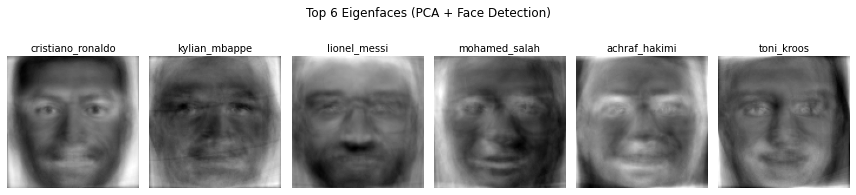

In [59]:
eigenfaces = pca.components_.reshape((-1, IMG_SIZE[0], IMG_SIZE[1]))

plt.figure(figsize=(12, 3))

for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(eigenfaces[i], cmap="gray")
    plt.title(PLAYERS[i], fontsize=10)
    plt.axis("off")

plt.suptitle("Top 6 Eigenfaces (PCA + Face Detection)")
plt.tight_layout()
plt.show()

### Recognition function

In [60]:
def recognize_face(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return "Invalid image"

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    face = detect_face(gray)
    if face is None:
        return "No face detected"

    # Preprocess face
    face_flat = preprocess_face(face).reshape(1, -1)

    # PCA → LDA
    face_pca = pca.transform(face_flat)
    face_lda = lda.transform(face_pca)

    # SVM prediction (numeric label)
    predicted_id = svm.predict(face_lda)[0]

    # Distance to class centroid
    centroid = class_centroids[predicted_id]
    distance = euclidean(face_lda[0], centroid)

    # Open-set check
    if distance > DIST_THRESHOLD:
        return "Unknown person"
    else:
        # Decode numeric label to human-readable name
        person_name = label_encoder.inverse_transform([predicted_id])[0]
        return f"Recognized as {person_name}"

### Evaluate the model

In [61]:
test_set = {}


for player in PLAYERS:
    subject_path = os.path.join(TEST_DIR, player)

    for img_name in os.listdir(subject_path):
        img_path = f'{subject_path}/{img_name}'
        test_set[img_path] = player

for i in range(1, 41):
    subject_path = f'{TEST_DIR}/s{i}'
    for img_name in os.listdir(subject_path):
        img_path = f'{subject_path}/{img_name}'
        test_set[img_path] = f's{i}'
        
for img_name in os.listdir(f'{TEST_DIR}/unknown'):
    img_path = f'{TEST_DIR}/unknown/{img_name}'
    test_set[img_path] = 'unknown'


In [62]:
TP = FP = TN = FN = 0

for img_path, true_label in test_set.items():
    result = recognize_face(img_path)
    if true_label == "unknown":
        if result == "Unknown person":
            TN += 1
        else:
            FP += 1
    else:
        if result == "Unknown person":
            FN += 1
        elif result == f"Recognized as {true_label}":
            TP += 1
        else:
            FN += 1

print(TP) # True Positive
print(FP) # False Positive
print(TN) # True Negative
print(FN) # False Negative

115
3
5
29


### ROC curve

In [63]:
y_true = []   # 1 = known, 0 = unknown
y_scores = [] # confidence score

for img_path, true_label in test_set.items():
    img = cv2.imread(img_path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
    face = detect_face(gray)
    if face is None:
        continue
    
    # face = cv2.resize(face, IMG_SIZE)
    face_flat = preprocess_face(face).reshape(1, -1)

    face_pca = pca.transform(face_flat)
    face_fisher = lda.transform(face_pca)

    predicted_label = svm.predict(face_fisher)[0]
    centroid = class_centroids[predicted_label]
    distance = euclidean(face_fisher[0], centroid)

    # Known = 1, Unknown = 0
    y_true.append(0 if true_label == "unknown" else 1)

    # Invert distance so higher = more confident
    y_scores.append(-distance)

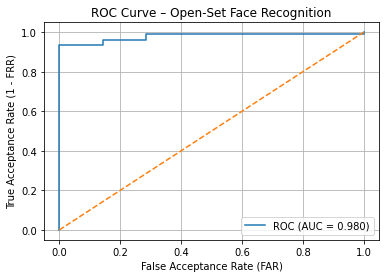

In [64]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Acceptance Rate (FAR)")
plt.ylabel("True Acceptance Rate (1 - FRR)")
plt.title("ROC Curve – Open-Set Face Recognition")
plt.legend()
plt.grid(True)
plt.show()


### Confusion matrix

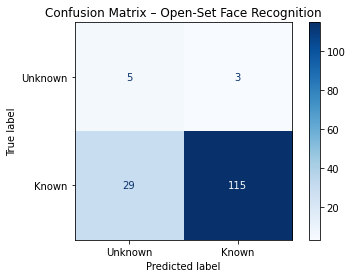

In [65]:
cm = np.array([
    [TN, FP],
    [FN, TP]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Unknown", "Known"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Open-Set Face Recognition")
plt.show()

### Save Models

In [66]:
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(pca, f"{MODELS_DIR}/pca_eigenfaces.pkl")
joblib.dump(lda, f"{MODELS_DIR}/lda_fisherface.pkl")
joblib.dump(svm, f"{MODELS_DIR}/svm_classifier.pkl")
joblib.dump(class_centroids, f"{MODELS_DIR}/class_centroids.pkl")
joblib.dump(DIST_THRESHOLD, f"{MODELS_DIR}/distance_threshold.pkl")
joblib.dump(label_encoder, f"{MODELS_DIR}/label_encoder.pkl")

print("All models saved successfully.")

All models saved successfully.


In [81]:
# data\test\toni_kroos\cqTiS40GaP4MuwmXIjNzq.jpg
recognize_face('./data/test/toni_kroos/cqTiS40GaP4MuwmXIjNzq.jpg')

'Recognized as toni_kroos'

In [ ]:
# users = {}
# users_arr = []
# def format_name(name):
#     # Split by underscore
#     parts = name.split('_')
#     # Capitalize each part
#     capitalized_parts = [part.capitalize() for part in parts]
#     # Join with space
#     return ' '.join(capitalized_parts)

# for player in PLAYERS:
#     users[player] = {"name":format_name(player), "img":""}
#     users_arr.append(player)
# for i in range(1, 41):
#     users[f's{i}'] = {"name":f's{i}', "img":''}
#     users_arr.append(f's{i}')

In [69]:
# import os, shutil
# from nanoid import generate
# dest_folder = './faces'
# for user in users_arr:
#     src_folder = f'{TRAIN_DIR}/{user}'
#     file_basename = os.listdir(src_folder)[0]
    
#     if user == "achraf_hakimi" or user == "mohamed_salah":
#         file_basename = os.listdir(src_folder)[2]
        
#     file_extension = file_basename.split('.')[-1]
#     src_file = f'{src_folder}/{file_basename}'
#     if file_extension != "pgm":
#         dest_file = f'{dest_folder}/{generate()}.{file_extension}'
#         shutil.copy2(src_file, dest_file)
        
#     else:
#         dest_file = f'{dest_folder}/{generate()}.jpg'
#         img = cv2.imread(src_file, cv2.IMREAD_GRAYSCALE)
#         cv2.imwrite(dest_file, img)

#     users[user]['img'] = dest_file

In [70]:
# print(len(users))
# print(users["mohamed_salah"])

In [71]:
# import json
# with open("faces.json", "w", encoding="utf-8") as f:
#     json.dump(users, f, indent=4, ensure_ascii=False)

In [ ]:
import os, shutil
from nanoid import generate

for player in PLAYERS:
    player_dir = f'{TEST_DIR}/{player}'
    for image_file in os.listdir(player_dir):
        src_path = f'{player_dir}/{image_file}'
        dest_path = f'{player_dir}/{generate()}.jpg'
        
        shutil.copy2(src_path, dest_path)
        os.remove(src_path)
        
    